In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("train.csv")
# print(df.head())
# print(df.info())
# print(df.describe())
print(df.shape)
print(df.columns)

(1460, 81)
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 

In [5]:
# print(df.isnull())
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [6]:
# df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].mean())
# print(df.dropna(subset=['LotFrontage']).shape[0])

# Option 3: Count before and after
print(f"Rows before: {len(df)}")
# df.dropna(subset=['LotFrontage'], inplace=True)
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].mean())
print(f"Rows after: {len(df)}")
# df.dropna(subset=['Alley'], inplace=True)
print(df.shape)

Rows before: 1460
Rows after: 1460
(1460, 81)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

X = df[["LotFrontage", "LotArea", "OverallQual","TotalBsmtSF","LotFrontage","GarageCars"]]
y = df["SalePrice"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [8]:
model = LinearRegression()#Price = w1*feature1 + w2*feature2 + ... + b(y=mx+b)
#price = 100*size + 5000*rooms......so on 
# Takes input (X_train)
# Makes prediction
# Compares with actual (y_train)
# Adjusts weights
# Repeats many times
# 👉 This is optimization

model.fit(X_train,y_train)#Learn pattern from known data
y_pred = model.predict(X_test)#Learn pattern from known data

print(y_pred)
print(y_pred.shape)
# print(y_test.shape)
# print(y_test)


[ 95721.61092197 189982.47409274 141266.29364052 113073.92742646
 116787.70456594 349567.30020474 269525.87862625 193000.44974637
 126935.74492642 111822.89228045 185142.51374324 223767.19601713
 194086.7173697  163647.75285116 208550.76823354 195153.64303392
 228910.89806844 174785.1461536  209019.59466092  38489.78436012
 116942.69494388 288750.977553   230895.14951499 211786.32778677
 342702.28146402 284856.18963561  76577.35065152 161068.17855977
 178989.91700826 193615.72278979 196428.64662967 177178.5689016
 122362.10183536 215517.37442725  81449.51140801 132277.78091375
 110386.993081   114013.79593588 127143.63465277 176701.94258882
 150897.06147886 149530.93442587  26006.33156082 208052.28836271
 201818.41443379 185999.71723799 225088.12235391 181532.78063981
 171344.78006417 149396.35335422 478670.36999426 111594.38894238
 141072.88506372 174530.54164371 172105.96003573 177444.8294561
 122454.0055956  214557.17544752  40217.27286839 136021.75954258
 188835.37389607 116041.122

In [9]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

In [10]:
#error jugde
var = mae/(np.mean(df["SalePrice"]))*100
print(var)#On average, your model is off by ~17.28732546012541%

14.188455769215885


In [11]:
model = DecisionTreeRegressor()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
#error jugde
var = mae/(np.mean(df["SalePrice"]))*100
print(var)

18.541066464319176


In [14]:
# plt.hist(df["SalePrice"])

# plt.hist(df["SalePrice"], bins=30, edgecolor='black')

# plt.figure(figsize=(10,6))
# plt.title("Distribution of Sale Prices", fontsize=16)
# plt.xlabel("Sale Price", fontsize=12)
# plt.ylabel("Frequency", fontsize=12)

# # Add mean & median lines
# mean_val = df["SalePrice"].mean()
# median_val = df["SalePrice"].median()

# plt.axvline(mean_val, linestyle='dashed', linewidth=2, label=f"Mean: {int(mean_val)}")
# plt.axvline(median_val, linestyle='solid', linewidth=2, label=f"Median: {int(median_val)}")

# plt.legend()
# plt.grid(True)

# plt.hist(df["SalePrice"], bins=30, density=True, alpha=0.6)

# df["SalePrice"].plot(kind='kde')

# # plt.show()

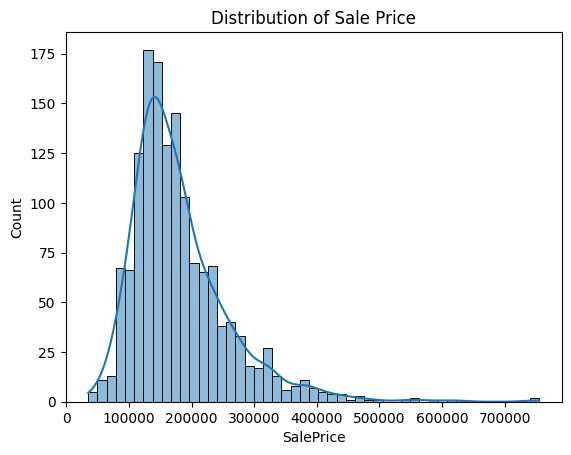

In [15]:

sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sale Price")
plt.show()

# Right Skewed Distribution (VERY IMPORTANT)
# Most values are on the left (lower prices)
# Tail is stretched to the right (high prices)


# Majority of Houses Range
# Most houses are between ~100k – 200k

# 👉 Insight:

# “Most properties fall in the mid-price range”

# Presence of Outliers
# Some values go up to 700k+

# 👉 Insight:

# “There are high-value outliers which may affect model performance”


In [17]:
df["SalePrice"] = np.log(df["SalePrice"])

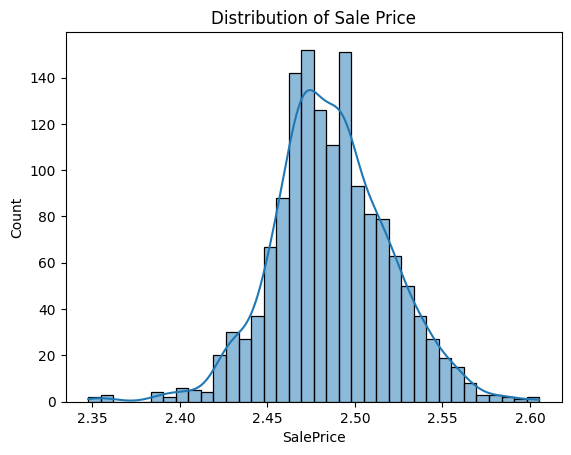

In [19]:

sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sale Price")
plt.show()

# Right Skewed Distribution (VERY IMPORTANT)
# Most values are on the left (lower prices)
# Tail is stretched to the right (high prices)


# Majority of Houses Range
# Most houses are between ~100k – 200k

# 👉 Insight:

# “Most properties fall in the mid-price range”

# Presence of Outliers
# Some values go up to 700k+

# 👉 Insight:

# “There are high-value outliers which may affect model performance”


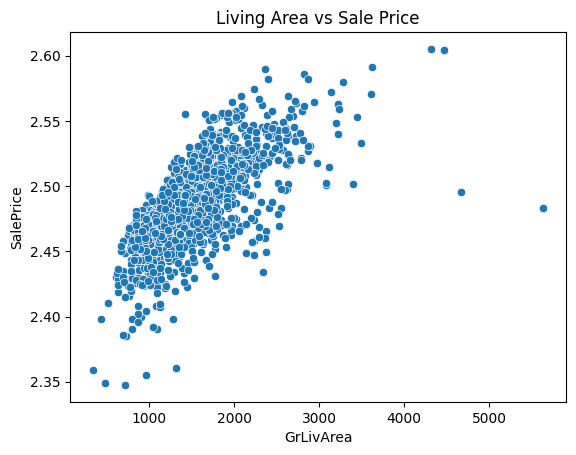

In [22]:
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.title("Living Area vs Sale Price")
plt.show()

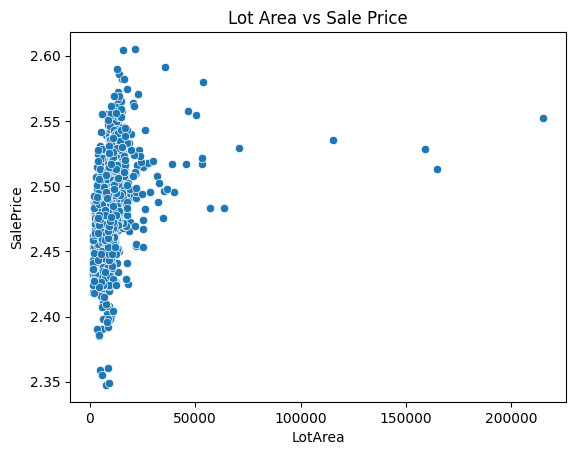

In [24]:
sns.scatterplot(x=df["LotArea"], y=df["SalePrice"])
plt.title("Lot Area vs Sale Price")
plt.show()

In [29]:
# print(df[["GrLivArea", "SalePrice"]].corr())

corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

top5 = corr[1:6]   # skip SalePrice itself (index 0)
print(top5)

OverallQual    0.814790
GrLivArea      0.696648
GarageCars     0.680087
GarageArea     0.649467
TotalBsmtSF    0.608866
Name: SalePrice, dtype: float64


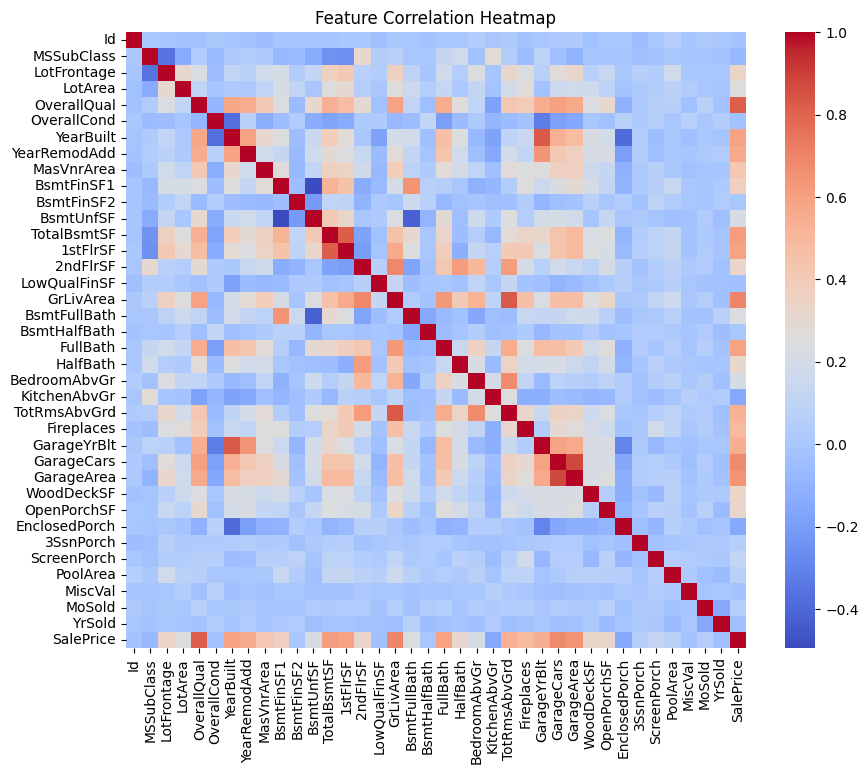

In [32]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")

plt.show()

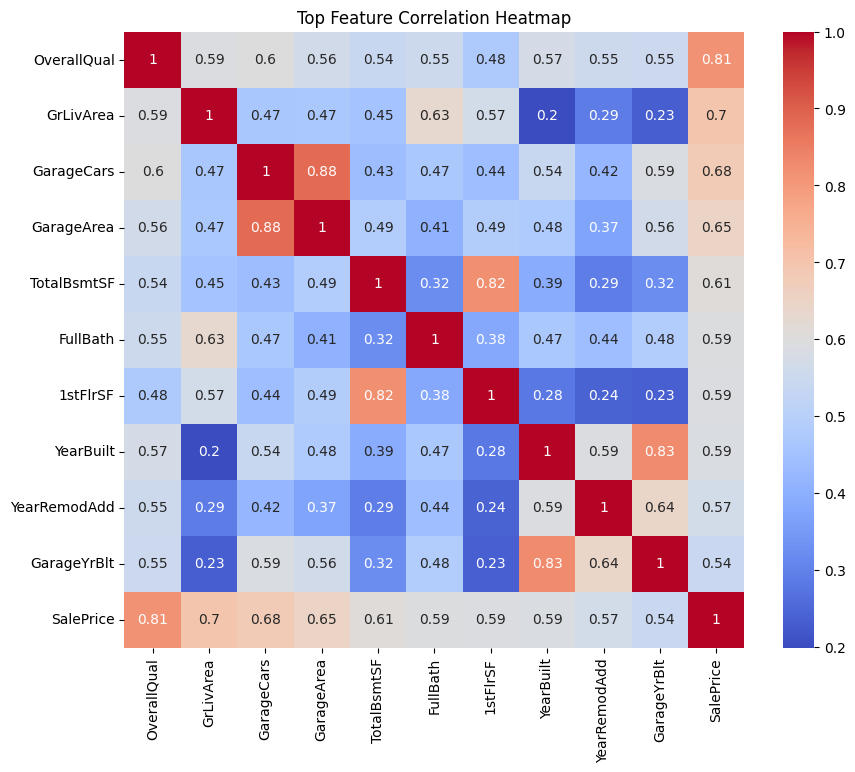

In [33]:
corr = df.corr(numeric_only=True)["SalePrice"].abs().sort_values(ascending=False)

top_features = corr.drop("SalePrice").head(10).index

plt.figure(figsize=(10,8))
sns.heatmap(df[top_features.tolist() + ["SalePrice"]].corr(), 
            annot=True, cmap="coolwarm")

plt.title("Top Feature Correlation Heatmap")
plt.show()